#Section 1 - Data Cleaning

## 1.1 Removing Missing Essential Identifiers

According to the methodology, records missing core identifiers must be removed.
Essential identifiers include:
- `spotify_id`
- `track_id`
- `name`
- `artist`
- `genre`

These fields are required to uniquely identify songs and ensure consistent analysis.


In [1]:
import pandas as pd

df = pd.read_csv("final_music_dataset.csv")

print("Before 1.1:", df.shape)

essential_cols = ["spotify_id", "track_id", "name", "artist", "genre"]
df = df.dropna(subset=essential_cols)

print("After 1.1:", df.shape)

Before 1.1: (50683, 26)
After 1.1: (22348, 26)


## 1.2 Removing Invalid Duration Values

Tracks with a duration of zero or negative values are invalid and should be removed.
This ensures audio-based features remain meaningful.


In [2]:
print("Before 1.2:", df.shape)

df = df[df["duration_ms"] > 0]

print("After 1.2:", df.shape)

Before 1.2: (22348, 26)
After 1.2: (22348, 26)


## 1.3 Removing Missing Spotify Popularity Values

The project's labels (`hit_label` and `popularity_level`) depend on Spotify popularity.
Rows without popularity cannot be used and must be removed.


In [3]:
print("Before 1.3:", df.shape)

df = df.dropna(subset=["popularity"])

print("After 1.3:", df.shape)

Before 1.3: (22348, 26)
After 1.3: (22348, 26)


## 1.4 Cleaning the Tags Column

The `tags` column represents social engagement signals.
Missing values are replaced with the placeholder `"none"` instead of being removed,
as tags are optional and not critical identifiers.


In [4]:
print("Before 1.4 missing tags:", df["tags"].isna().sum())

df["tags"] = df["tags"].fillna("none")

print("After 1.4 missing tags:", df["tags"].isna().sum())

Before 1.4 missing tags: 432
After 1.4 missing tags: 0


## 1.5 Handling Missing Audio Features

Machine learning models require complete input.  
Any missing MIR audio features are imputed using **median values**, as commonly recommended in MIR literature.
This ensures consistency without distorting feature distributions.


In [5]:
audio_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'key', 'mode', 'time_signature'
]

print("Before 1.5 missing values:")
print(df[audio_cols].isna().sum())

for col in audio_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nAfter 1.5 missing values:")
print(df[audio_cols].isna().sum())

Before 1.5 missing values:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
key                 0
mode                0
time_signature      0
dtype: int64

After 1.5 missing values:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
key                 0
mode                0
time_signature      0
dtype: int64


## 1.6 Saving the Cleaned Dataset

After completing all required cleaning steps (1.1–1.5),
the dataset is now ready for preprocessing and modelling.

We save it as `cleaned_music_dataset.csv`.


In [6]:
df.to_csv("cleaned_music_dataset.csv", index=False)
print("Cleaned dataset saved as cleaned_music_dataset.csv")

Cleaned dataset saved as cleaned_music_dataset.csv


#Section 2 - Preprocessing and Feature Preparation

## 2.1 Loading the Cleaned Dataset
The cleaned dataset from Section 1 is loaded for preprocessing and modelling.


In [7]:
# Load cleaned dataset
df = pd.read_csv("cleaned_music_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (22348, 26)


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,instrumentalness,liveness,valence,tempo,time_signature,popularity,spotify_name_api,spotify_artist_api,hit_label,popularity_level
0,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,0.000459,0.0878,0.543,120.012,4,1,Come As You Are,Nirvana,0,emerging
1,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,0.000141,0.1290,0.104,91.841,4,0,Creep,Radiohead,0,emerging
2,TRMZXEW128F9341FD5,The Scientist,Coldplay,https://p.scdn.co/mp3-preview/95cb9df1b056d759...,0GSSsT9szp0rJkBrYkzy6s,"rock, alternative, indie, pop, alternative_roc...",Rock,2007,311014,0.566,...,0.000014,0.1200,0.173,146.365,4,0,The Scientist,Coldplay,0,emerging
3,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",Pop,2003,265506,0.554,...,0.000534,0.1360,0.513,84.275,4,0,Under The Bridge,Red Hot Chili Peppers,0,emerging
4,TRYEZGE128F92D04C8,Feel Good Inc.,Gorillaz,https://p.scdn.co/mp3-preview/7388c425022ced92...,09xrHi86kLkEIzDLZiHNnv,"rock, electronic, alternative, indie, pop, alt...",RnB,2010,223106,0.809,...,0.001410,0.8260,0.832,138.556,4,0,Feel Good Inc,Gorillaz,0,emerging


## 2.2 Defining Feature Groups
Features are grouped into:
- Audio features
- Metadata features
- Social-engagement features (tags)

These groups support separate model training for RQ2.


In [8]:
# Audio feature columns
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'key', 'mode', 'time_signature'
]

# Metadata feature columns
metadata_features = [
    'genre', 'year', 'artist', 'name'
]

# Social-engagement feature columns
social_features = ['tags']

# Quick check that all columns exist
print("Audio features present:", all(col in df.columns for col in audio_features))
print("Metadata features present:", all(col in df.columns for col in metadata_features))
print("Social features present:", all(col in df.columns for col in social_features))

Audio features present: True
Metadata features present: True
Social features present: True


## 2.3 Defining the Target Variable
The binary `hit_label` is used as the target for all classification models.


In [9]:
# Target variable: binary hit label
y = df['hit_label']

# Start from all columns, then drop non-feature columns
drop_cols = ['hit_label', 'popularity_level', 'popularity',
             'spotify_id', 'track_id']  # IDs and labels not used as predictors

X = df.drop(columns=drop_cols)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (22348, 21)
Target distribution:
hit_label
0    22200
1      148
Name: count, dtype: int64


## 2.3a Dropping Irrelevant Text Columns
Remove `spotify_preview_url` as it is not a predictive feature.


In [15]:
# Redefine target
y = df['hit_label']

# Drop IDs, labels, and non-useful text columns
drop_cols = [
    'hit_label',
    'popularity_level',
    'popularity',
    'spotify_id',
    'track_id',
    'spotify_preview_url'   # 👈 added
]

X = df.drop(columns=drop_cols)

print("Feature matrix shape:", X.shape)
print("Columns in X:", X.columns.tolist())

Feature matrix shape: (22348, 20)
Columns in X: ['name', 'artist', 'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'spotify_name_api', 'spotify_artist_api']


## 2.4 Identifying Numeric and Categorical Features
Explicitly set audio + year as numeric, and text fields as categorical.


In [20]:
# Categorical columns: text-based metadata + tags
categorical_cols = ['genre', 'tags', 'artist', 'name']

# Numeric columns: audio features + year
numeric_cols = audio_features + ['year']

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode', 'time_signature', 'year']
Categorical columns: ['genre', 'tags', 'artist', 'name']


## 2.5 Building the Preprocessing Pipeline
A ColumnTransformer is created to:
- Standardise numeric features
- One-hot encode categorical features


In [21]:
# Define the preprocessing for numeric and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['danceability', 'energy', 'loudness',
                                  'speechiness', 'acousticness',
                                  'instrumentalness', 'liveness', 'valence',
                                  'tempo', 'duration_ms', 'key', 'mode',
                                  'time_signature', 'year']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['genre', 'tags', 'artist', 'name'])])

## 2.6 Summary of Preprocessing Setup

At this point, the dataset has been:

- Cleaned according to the methodology (Section 1).
- Organised into feature groups (audio, metadata, social-engagement).
- Split into:
  - Feature matrix `X`
  - Target vector `y` (`hit_label`)
- Assigned into numeric and categorical feature subsets.
- Associated with a `ColumnTransformer` (`preprocessor`) that standardises numeric features
  and one-hot encodes categorical features.

This preprocessing pipeline will now be integrated with the classification models
(Logistic Regression and XGBoost) in the next section.


#Section 3- Model Development

## 3.0 Train–Test Split
Split the dataset into training and testing sets (80/20) using stratification.


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (17878, 20)
Testing set: (4470, 20)


## 3.1 Logistic Regression Model
Train a baseline, interpretable model using class_weight='balanced'.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# Build logistic regression pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4440
           1       0.06      0.03      0.04        30

    accuracy                           0.99      4470
   macro avg       0.52      0.51      0.52      4470
weighted avg       0.99      0.99      0.99      4470

ROC-AUC: 0.7525975975975976


## 3.2 XGBoost Classifier
Train a non-linear model using scale_pos_weight for imbalance.



In [24]:
from xgboost import XGBClassifier

# Imbalance ratio for scale_pos_weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4440
           1       0.33      0.07      0.11        30

    accuracy                           0.99      4470
   macro avg       0.66      0.53      0.55      4470
weighted avg       0.99      0.99      0.99      4470

ROC-AUC: 0.6115240240240241


## 3.3 Feature-Group Models (RQ2)
Train separate Logistic Regression models for audio-only, metadata-only, tags-only, and full features.


In [25]:
# Audio-only: audio features + year
X_train_audio = X_train[audio_features + ['year']]
X_test_audio  = X_test[audio_features + ['year']]

# Metadata-only: genre, artist, name, year
meta_features = ['genre', 'artist', 'name', 'year']
X_train_meta = X_train[meta_features]
X_test_meta  = X_test[meta_features]

# Tags-only: tags only
X_train_tags = X_train[['tags']]
X_test_tags  = X_test[['tags']]

# Full multimodal: all features already in X_train / X_test
X_train_full = X_train.copy()
X_test_full  = X_test.copy()

## 3.4 Evaluating Each Feature Group
Use a small helper to train and report F1 and ROC-AUC for each group.


In [26]:
from sklearn.metrics import f1_score

def evaluate_group(Xtr, Xte, ytr, yte,
                   num_cols, cat_cols,
                   group_name="group"):
    # Preprocessor for this group
    group_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    model = Pipeline(steps=[
        ('preprocessor', group_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ])

    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    print(f"\n=== {group_name} ===")
    print("F1-score:", f1_score(yte, preds))
    print("ROC-AUC:", roc_auc_score(yte, proba))
    return model

## 3.5 RQ2 Results: Audio vs Metadata vs Tags vs Full
Train and compare performance across feature groups.


In [27]:
# Audio-only
audio_num = audio_features + ['year']
audio_cat = []  # no categorical in this subset
lr_audio = evaluate_group(X_train_audio, X_test_audio, y_train, y_test,
                          audio_num, audio_cat, "Audio-only")

# Metadata-only
meta_num = ['year']
meta_cat = ['genre', 'artist', 'name']
lr_meta = evaluate_group(X_train_meta, X_test_meta, y_train, y_test,
                         meta_num, meta_cat, "Metadata-only")

# Tags-only
tags_num = []
tags_cat = ['tags']
lr_tags = evaluate_group(X_train_tags, X_test_tags, y_train, y_test,
                         tags_num, tags_cat, "Tags-only")

# Full multimodal (for comparison)
full_num = audio_features + ['year']
full_cat = ['genre', 'artist', 'name', 'tags']
lr_full = evaluate_group(X_train_full, X_test_full, y_train, y_test,
                         full_num, full_cat, "Full multimodal")


=== Audio-only ===
F1-score: 0.02467811158798283
ROC-AUC: 0.6725075075075075

=== Metadata-only ===
F1-score: 0.03333333333333333
ROC-AUC: 0.6593581081081081

=== Tags-only ===
F1-score: 0.0365296803652968
ROC-AUC: 0.6177327327327327

=== Full multimodal ===
F1-score: 0.041666666666666664
ROC-AUC: 0.7525975975975976


#Section 4 - SHAH INTERPRETABILITY

## 4.1 SHAP Setup
Use TreeExplainer on the trained XGBoost model for global and local explanations.


In [28]:
import shap

# Extract trained XGBoost classifier inside pipeline
xgb_clf = xgb_model.named_steps['classifier']

# Transform X_test through the pipeline’s preprocessor
X_test_transformed = xgb_model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing (OH-encoded)
ohe = xgb_model.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)
final_feature_names = numeric_cols + list(ohe_features)

print("Total transformed features:", len(final_feature_names))

Total transformed features: 31387


## 4.2 Global SHAP Values
Compute global feature importance to identify which factors most influence popularity.


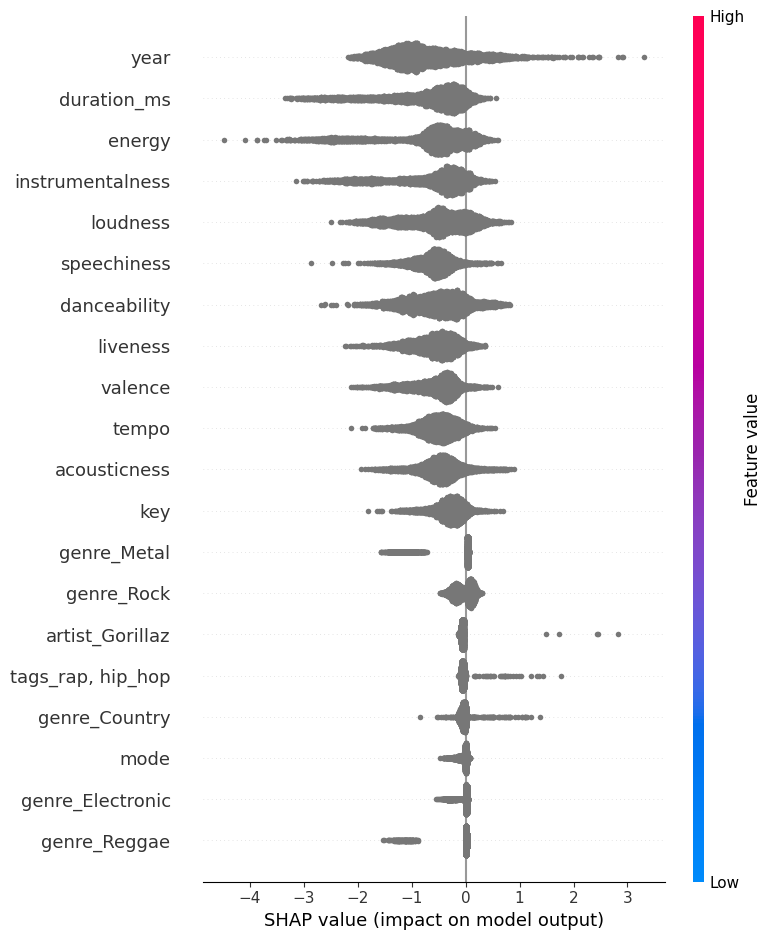

In [29]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_clf)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_test_transformed, feature_names=final_feature_names)

## 4.3 Local SHAP Explanation for a Single Track
Visualise the top contributing features for one example prediction.


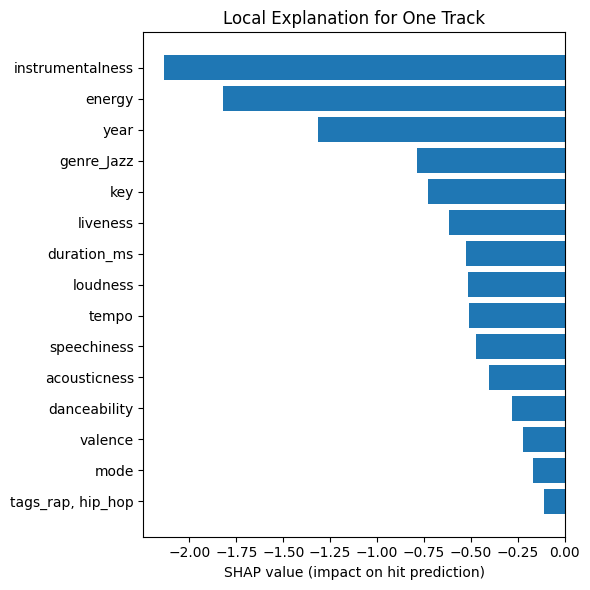

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Choose one test sample (e.g. first one)
idx = 0
sample_shap = shap_values[idx]
sample_features = X_test_transformed[idx]

# Get top 15 features by absolute SHAP value
top_idx = np.argsort(np.abs(sample_shap))[-15:]
top_shap = sample_shap[top_idx]
top_names = np.array(final_feature_names)[top_idx]

# Plot horizontal bar chart
plt.figure(figsize=(6, 6))
y_pos = np.arange(len(top_names))
plt.barh(y_pos, top_shap)
plt.yticks(y_pos, top_names)
plt.xlabel("SHAP value (impact on hit prediction)")
plt.title("Local Explanation for One Track")
plt.tight_layout()
plt.show()


## 4.4 SHAP by Popularity Level
Create masks for emerging, moderate and viral tracks using test indices.


In [33]:
import numpy as np

# Map test indices to popularity_level
test_indices = y_test.index
pop_levels_test = df.loc[test_indices, 'popularity_level']

# Boolean masks (as NumPy arrays)
emerging_mask = (pop_levels_test == "emerging").values
moderate_mask = (pop_levels_test == "moderately_popular").values
viral_mask    = (pop_levels_test == "viral").values

# Index arrays for each group
emerging_idx = np.where(emerging_mask)[0]
moderate_idx = np.where(moderate_mask)[0]
viral_idx    = np.where(viral_mask)[0]

print("Emerging samples:", emerging_idx.shape[0])
print("Moderate samples:", moderate_idx.shape[0])
print("Viral samples:", viral_idx.shape[0])

Emerging samples: 4259
Moderate samples: 205
Viral samples: 6


## 4.5 SHAP Summary per Popularity Group
Subset SHAP values and features for each group to compare feature importance.


Emerging Tracks:


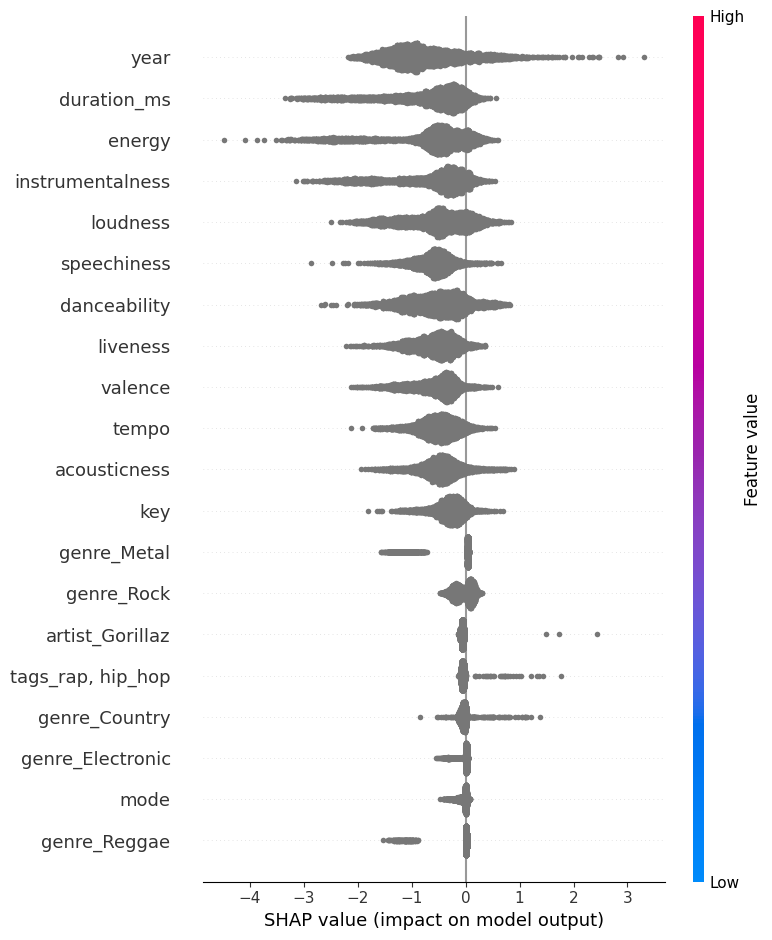

Moderately Popular Tracks:


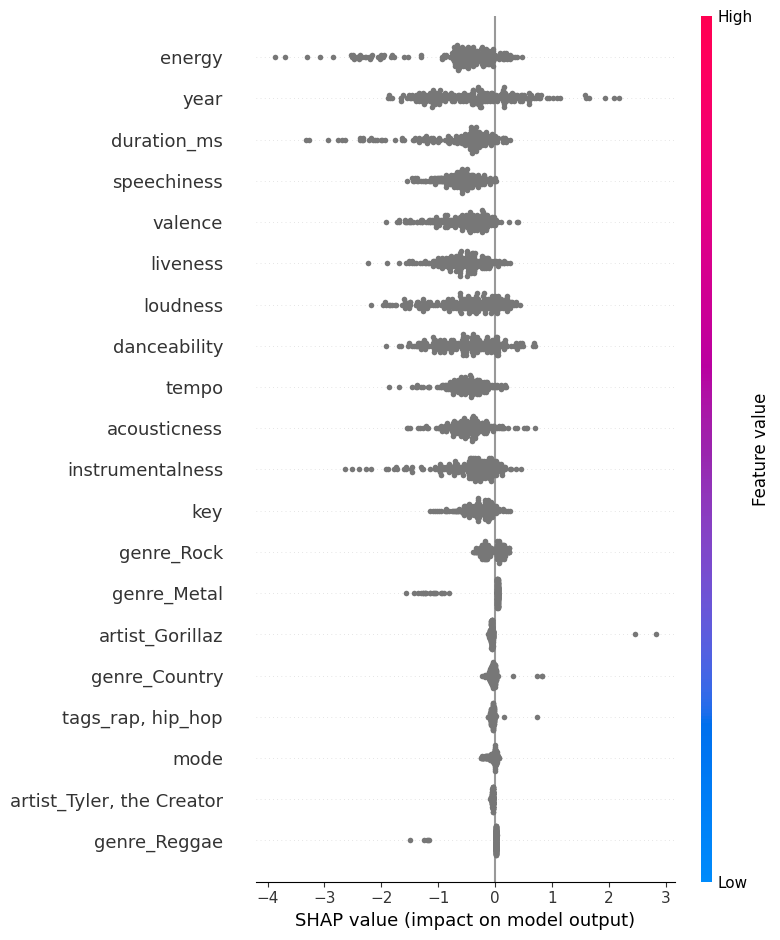

Viral Tracks:


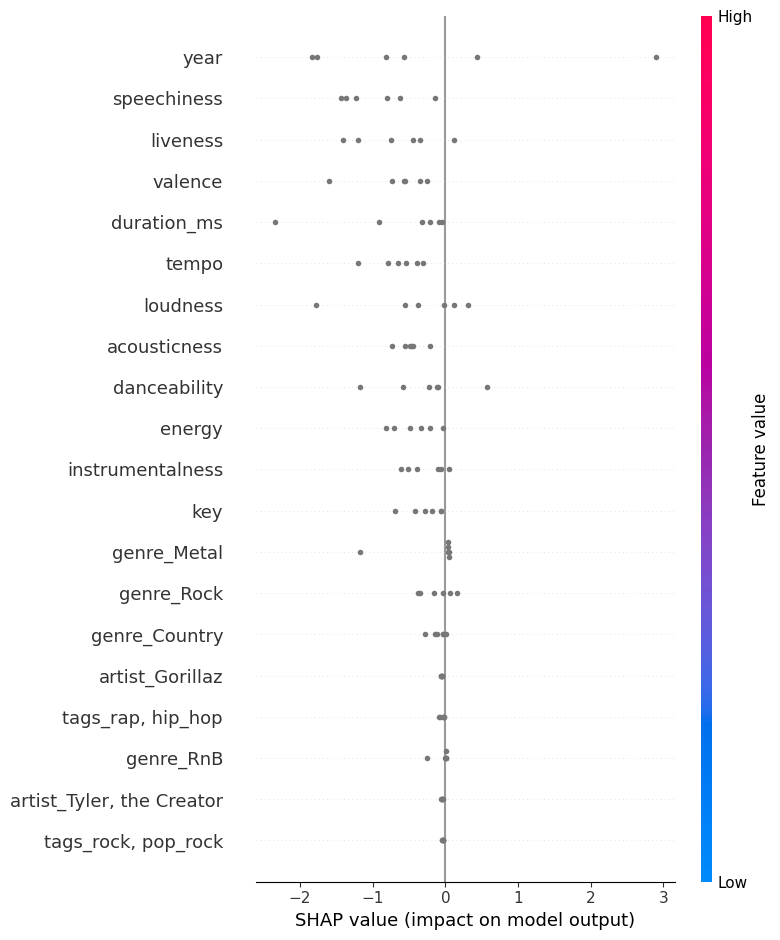

In [34]:
# Subset transformed features
X_emerging = X_test_transformed[emerging_idx]
X_moderate = X_test_transformed[moderate_idx]
X_viral    = X_test_transformed[viral_idx]

# Subset SHAP values
shap_emerging = shap_values[emerging_idx]
shap_moderate = shap_values[moderate_idx]
shap_viral    = shap_values[viral_idx]

print("Emerging Tracks:")
shap.summary_plot(shap_emerging, X_emerging, feature_names=final_feature_names)

print("Moderately Popular Tracks:")
shap.summary_plot(shap_moderate, X_moderate, feature_names=final_feature_names)

print("Viral Tracks:")
shap.summary_plot(shap_viral, X_viral, feature_names=final_feature_names)

## 4.6 Precision@K
Evaluate how many true hits appear in the top-K highest scoring predictions.


In [35]:
import numpy as np

def precision_at_k(y_true, y_scores, k):
    # Sort by predicted probability
    top_k_idx = np.argsort(y_scores)[-k:]
    top_k_true = y_true.iloc[top_k_idx]
    return top_k_true.mean()

# Use XGBoost predicted probabilities
y_scores = y_proba_xgb  # from your 3.2 step

print("Precision@10 :", precision_at_k(y_test, y_scores, 10))
print("Precision@50 :", precision_at_k(y_test, y_scores, 50))
print("Precision@100:", precision_at_k(y_test, y_scores, 100))

Precision@10 : 0.2
Precision@50 : 0.04
Precision@100: 0.02
